# Notebook 2 - FErules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import LinearSVC
from scipy.stats import entropy
from imblearn.over_sampling import SMOTE
import shap
!pip install wittgenstein
import wittgenstein as lw
from itertools import product

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for wittgenstein: filename=wittgenstein-0.3.5-py3-none-any.whl size=98989 sha256=327ed936ef1d38fee2bc79811774af213a843d98e05ff1e319deb5d073cc1d50
  Stored in directory: /root/.cache/pip/wheels/ed/c4/1c/36ab0b352b6fc249d4bb154081713e3a42c868994e8aaa74de
Successfully built wittgenstein


# 1. Učitavanje skupa podataka

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mrossini03/cleaned-data/cleaned_data.csv')
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,air_temperature,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0000,0,Education,7432,25.0,20.0,0.0,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.0000,0,Education,2720,25.0,20.0,0.0,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.0000,0,Education,5376,25.0,20.0,0.0,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.0000,0,Education,23685,25.0,20.0,0.0,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.0000,0,Education,116607,25.0,20.0,0.0,1019.7,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32870690,1323,1,2017-12-31 23:00:00,0.0000,14,Office,87200,-11.1,-20.6,0.0,1026.2,330.0,2.6
32870691,1323,3,2017-12-31 23:00:00,811265.2506,14,Office,87200,-11.1,-20.6,0.0,1026.2,330.0,2.6
32870692,1324,0,2017-12-31 23:00:00,14.0000,14,Entertainment/public assembly,84688,-11.1,-20.6,0.0,1026.2,330.0,2.6
32870693,1324,1,2017-12-31 23:00:00,0.0000,14,Entertainment/public assembly,84688,-11.1,-20.6,0.0,1026.2,330.0,2.6


# 2. Stvaranje ciljne varijable is_residential i provjera nebalansiranosti klasa

Prvi zadatak je napraviti ciljnu varijablu `is residential` u predviđanju je li zgrada stambena.

In [3]:
df["is_residential"] = (df["primary_use"] == "Lodging/residential").astype(int)

counts = df["is_residential"].value_counts()
ratio  = counts[0] / counts[1]

print(counts)
print(f"Omjer nestambenih zgrada i stambenih zgrada: {ratio:.1f}:1")

is_residential
0    29468397
1     3402298
Name: count, dtype: int64
Omjer nestambenih zgrada i stambenih zgrada: 8.7:1


Problem nebalansiranosti može dovesti do nepravilnog učenja modela te može doći do problema da model manjinsku klasu smatra šumom većinske klase. Zato moramo koristiti metode uzorkovanja.

In [4]:
drop_cols   = ["is_residential", "primary_use"]
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in drop_cols]

X = df[feature_cols]
X_values = X.values
y = df["is_residential"]

print(f"Shape: {X.shape}, features: {len(feature_cols)}")
#X

Shape: (32870695, 11), features: 11


# 3. Modeli

Četiri modela koja ćemo uspoređivati su GaussianNB, logistička regresija, RandomForest i XGBClassifier. U nastavku se nalaze modeli, za koje će biti korišteni defaultni hiperparametri, osim za RandomForest, zbog manje složenosti izvođenja.

In [5]:
models = {
        "GaussianNB": GaussianNB(),
        "LogisticRegression": LogisticRegression(random_state=42),
        "RandomForestClassifier": RandomForestClassifier(n_estimators=20, max_depth=10, min_samples_split=5, n_jobs=-1, random_state=42),
        "XGBClassifier": XGBClassifier(random_state=42)
    }

# 4. Cross-validation funkcija

Ovdje je funkcija cross-validacije koja će biti korištena u nastavku bilježnice. 

In [6]:
def cross_validation(X, y, models, sampler=None, return_results=False):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    results = {}
    for name, model in models.items():
        fold_scores = []
        
        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)
            
            if sampler is not None:
                X_train, y_train = sampler.fit_resample(X_train, y_train)
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            fold_scores.append(round(f1_score(y_test, y_pred, zero_division=0), 4))
        
        results[name] = fold_scores
        if not return_results:
            print(f"{name}: {fold_scores}, AVG: {np.mean(fold_scores):.4f}")

    if return_results:
        return results

Sad ću provesti cross-validaciju na skupu podataka bez uzorkovanja i sa poduzorkovanjem. S obzirom da orginalni skup podataka ima preko 32 milijuna redaka što zahtjeva iznimno velike resurse za izvođenje, cross-validacija će biti provedena na 10% podataka, što je i dalje preko 3 milijuna podataka.

## 4.1. Podaci koji nisu poduzorkovani

In [7]:
df_subsampled = df.sample(frac=0.1, random_state=42)
X_sub = df_subsampled[feature_cols].values
y_sub = df_subsampled["is_residential"].values

In [8]:
cross_validation(X_sub, y_sub, models, sampler=None)

GaussianNB: [0.1964, 0.1974, 0.1974, 0.1977, 0.1974], AVG: 0.1973
LogisticRegression: [0.0, 0.0, 0.0, 0.0, 0.0], AVG: 0.0000
RandomForestClassifier: [0.5637, 0.5463, 0.5347, 0.5435, 0.5718], AVG: 0.5520
XGBClassifier: [0.9968, 0.9983, 0.9988, 0.9989, 0.9982], AVG: 0.9982


## 4.2. Poduzorkovani podaci

In [9]:
cross_validation(X_sub, y_sub, models, sampler=RandomUnderSampler(random_state=42))

GaussianNB: [0.189, 0.1893, 0.1893, 0.1891, 0.189], AVG: 0.1891
LogisticRegression: [0.2061, 0.2067, 0.2074, 0.2066, 0.2062], AVG: 0.2066
RandomForestClassifier: [0.6831, 0.6444, 0.6432, 0.6613, 0.6192], AVG: 0.6502
XGBClassifier: [0.9997, 0.9988, 0.9945, 0.999, 0.9997], AVG: 0.9983


Bolji rezultat ostvario je poduzorkovani skup podataka, a razlika se najviše osjeti na modelu logističke regresije i modelu RandomForest.

# 5. Agregirani skup podataka

Agregirani skup podataka sadržavat će jedan red po zgradi, dakle u sebi će sadržavati broj redova koliko postoji različitih zgrada, a značajke će biti srednje vrijednosti, medijani, standardne devijacije i slične vrijednosti za značajke u orginalnom skupu podataka grupirane po zgradi.

## 5.1. Izrada skupa podataka

In [10]:
agg_dict = {
    'meter_reading': ['mean', 'median', 'max', 'std'],
    
    'air_temperature': ['mean', 'median', 'max', 'min', 'std'],
    'dew_temperature': ['mean', 'median', 'max', 'min', 'std'],
    'precip_depth_1_hr': ['mean', 'max'],
    'sea_level_pressure': ['mean', 'std'],
    'wind_direction': ['mean', 'std'],
    'wind_speed': ['mean', 'max', 'std'],

    'site_id': 'first',
    'square_feet': 'first',
}

df_agg = df.groupby('building_id').agg(agg_dict)

df_agg.columns = ['_'.join(col).strip() for col in df_agg.columns]
df_agg = df_agg.reset_index()

is_residential = df.groupby('building_id')['is_residential'].first()
df_agg = df_agg.merge(is_residential, on='building_id')

df_agg = pd.get_dummies(df_agg, columns=['is_residential'])
df_agg["is_residential"] = (df_agg["is_residential_1"] == True).astype(int)
df_agg.drop(columns=["is_residential_0", "is_residential_1"], inplace=True)

df_agg


,building_id,meter_reading_mean,meter_reading_median,meter_reading_max,meter_reading_std,air_temperature_mean,air_temperature_median,air_temperature_max,air_temperature_min,air_temperature_std,...,sea_level_pressure_mean,sea_level_pressure_std,wind_direction_mean,wind_direction_std,wind_speed_mean,wind_speed_max,wind_speed_std,site_id_first,square_feet_first,is_residential
0,0,104.367531,64.2124,4.480000e+02,96.410110,22.805227,23.9,36.1,1.7,5.794938,...,1017.725832,4.504939,152.378724,116.808060,3.394630,24.2,2.233999,0,7432,0
1,1,53.786548,37.9273,2.550000e+02,48.927291,22.805227,23.9,36.1,1.7,5.794939,...,1017.725837,4.504940,152.378796,116.793981,3.394630,24.2,2.233999,0,2720,0
2,2,10.554314,6.1430,6.798300e+01,12.459719,22.803878,23.9,36.1,1.7,5.794065,...,1017.726601,4.504062,152.342989,116.765631,3.395021,24.2,2.233706,0,5376,0
3,3,155.783341,92.3178,9.370000e+02,168.454760,22.804163,23.9,36.1,1.7,5.794107,...,1017.726454,4.504146,152.331786,116.745754,3.395129,24.2,2.233724,0,23685,0
4,4,683.255738,413.0797,3.592000e+03,626.375904,22.804128,23.9,36.1,1.7,5.793996,...,1017.726365,4.504054,152.346421,116.735996,3.395004,24.2,2.233643,0,116607,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1124,1320,129.666149,114.0460,3.547190e+02,55.735614,13.177384,13.3,35.6,-15.6,10.092471,...,1016.147759,7.607835,186.338805,122.296249,3.075531,13.4,2.063233,14,34565,0
1125,1321,84335.133570,435.0000,1.741619e+06,234148.598174,13.169648,13.3,35.6,-15.6,10.044889,...,1016.128764,7.592306,186.360438,122.360825,3.074839,13.4,2.064361,14,370024,0
1126,1322,58303.766719,191.0510,1.466270e+06,159136.220440,13.181180,13.3,35.6,-15.6,10.099191,...,1016.139323,7.608927,186.379663,122.340884,3.077002,13.4,2.063634,14,166489,0
1127,1323,98245.748413,885.6710,1.260778e+06,196182.894364,13.231634,13.3,35.6,-15.6,10.053532,...,1016.110169,7.575889,186.271854,122.321878,3.076457,13.4,2.063023,14,87200,0


## 5.2. Provjera omjera stambenih i nestambenih zgrada

Provjerit ću omjer stambenih i nestambenih zgrada u novo izgrađenom agregiranom skupu podataka.

In [11]:
counts = df_agg["is_residential"].value_counts()
ratio  = counts[0] / counts[1]

print(counts)
print(f"Omjer nestambenih zgrada i stambenih zgrada: {ratio:.1f}:1")

is_residential
0    1022
1     107
Name: count, dtype: int64
Omjer nestambenih zgrada i stambenih zgrada: 9.6:1


In [12]:
feature_cols = [c for c in df_agg.select_dtypes(include=[np.number]).columns
                if c not in drop_cols]

X_agg = df_agg[feature_cols]
X_agg_values = X_agg.values
y_agg = df_agg["is_residential"]

print(f"Shape: {X_agg.shape}, features: {len(feature_cols)}")

Shape: (1129, 26), features: 26


## 5.3. Provođenje cross-validacije

Provest ću cross-validaciju na agregiranom skupu podataka. Prvo bez uzorkovanja, a zatim s naduzorkovanjem. Ovaj put sam se odlučio za naduzorkovanje umjesto poduzorkovanja jer novi skup podataka ima samo malo iznad 1000 redaka, što je mala količina podataka.

In [13]:
cross_validation(X_agg_values, y_agg, models, sampler=None)

GaussianNB: [0.1753, 0.1848, 0.1836, 0.1776, 0.1951], AVG: 0.1833
LogisticRegression: [0.0, 0.0, 0.0, 0.0, 0.0], AVG: 0.0000
RandomForestClassifier: [0.5, 0.16, 0.2143, 0.2857, 0.25], AVG: 0.2820
XGBClassifier: [0.4615, 0.3448, 0.4848, 0.1538, 0.2667], AVG: 0.3423


In [14]:
cross_validation(X_agg_values, y_agg, models, sampler = SMOTE(random_state=42))

GaussianNB: [0.1887, 0.1731, 0.1827, 0.1784, 0.1905], AVG: 0.1827
LogisticRegression: [0.268, 0.26, 0.3119, 0.233, 0.2642], AVG: 0.2674
RandomForestClassifier: [0.3774, 0.45, 0.5091, 0.3902, 0.4082], AVG: 0.4270
XGBClassifier: [0.4528, 0.4545, 0.4615, 0.4211, 0.3333], AVG: 0.4246


Opet, dobiveni su bolji rezultati korištenjem metoda uzorkovanja koje će se koristiti u daljnjem tijeku bilježnice.

# 6. Nove značajke

## 6.1. Dodavanje novih značajki

Ovdje ću dodati nove značajke na agregirani skup podataka. Neke od novo dodanih značajki bit će energy_intensity, night_day_ratio, weekend_weekday_ratio, peak_consumption_fraction, cv_consumption, volatility_ratio i consumption_entropy.

In [15]:
df_fe = df.copy()

df_fe['timestamp'] = pd.to_datetime(df_fe['timestamp'])
df_fe = df_fe.sort_values(['building_id', 'meter', 'timestamp'])

df_fe['hour'] = df_fe['timestamp'].dt.hour
df_fe['dayofweek'] = df_fe['timestamp'].dt.dayofweek

df_fe['energy_intensity'] = df_fe['meter_reading'] / (df_fe['square_feet'] + 1e-9)

df_fe['wind_chill'] = df_fe['air_temperature'] - 0.7 * df_fe['wind_speed']

df_fe['is_peak'] = df_fe['hour'].between(8, 18).astype(int)
df_fe['peak_consumption'] = df_fe['meter_reading'] * df_fe['is_peak']

df_fe['is_night'] = df_fe['hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
df_fe['night_consumption'] = df_fe['meter_reading'] * df_fe['is_night']
df_fe['day_consumption'] = df_fe['meter_reading'] * (1 - df_fe['is_night'])

df_fe['is_weekend'] = df_fe['dayofweek'].isin([5, 6]).astype(int)
df_fe['weekend_consumption'] = df_fe['meter_reading'] * df_fe['is_weekend']
df_fe['weekday_consumption'] = df_fe['meter_reading'] * (1 - df_fe['is_weekend'])

df_fe['is_raining'] = (df_fe['precip_depth_1_hr'] > 0).astype(int)

grp = df_fe.groupby(['building_id', 'meter'])['meter_reading']

df_fe['rolling_mean_24h'] = grp.transform(lambda x: x.rolling(24,  min_periods=1).mean())
df_fe['rolling_std_24h'] = grp.transform(lambda x: x.rolling(24,  min_periods=1).std().fillna(0))

df_fe['rolling_mean_7d'] = grp.transform(lambda x: x.rolling(168, min_periods=1).mean())
df_fe['rolling_std_7d'] = grp.transform(lambda x: x.rolling(168, min_periods=1).std().fillna(0))

df_fe['expanding_mean'] = grp.transform(lambda x: x.expanding().mean())

df_agg_full = df_fe.groupby('building_id').agg(

    meter_reading_mean = ('meter_reading', 'mean'),
    meter_reading_median = ('meter_reading', 'median'),
    meter_reading_max = ('meter_reading', 'max'),
    meter_reading_std = ('meter_reading', 'std'),
    square_feet = ('square_feet', 'first'),
    site_id = ('site_id', 'first'),
    meter_types = ('meter', 'nunique'),
    air_temp_mean = ('air_temperature', 'mean'),
    air_temp_std = ('air_temperature', 'std'),
    dew_temp_mean = ('dew_temperature', 'mean'),
    dew_temp_std = ('dew_temperature', 'std'),
    precip_mean = ('precip_depth_1_hr', 'mean'),
    precip_max = ('precip_depth_1_hr', 'max'),
    sea_level_pressure_mean = ('sea_level_pressure', 'mean'),
    wind_direction_mean = ('wind_direction', 'mean'),
    wind_direction_std = ('wind_direction', 'std'),
    wind_speed_mean = ('wind_speed', 'mean'),
    wind_speed_max = ('wind_speed', 'max'),
    wind_speed_std = ('wind_speed', 'std'),

    energy_intensity_mean = ('energy_intensity', 'mean'),
    energy_intensity_max = ('energy_intensity', 'max'),
    wind_chill_mean = ('wind_chill', 'mean'),
    rain_fraction = ('is_raining', 'mean'),
    peak_consumption_mean = ('peak_consumption', 'mean'),
    night_consumption_mean = ('night_consumption', 'mean'),
    day_consumption_mean = ('day_consumption', 'mean'),
    weekend_consumption_mean = ('weekend_consumption', 'mean'),
    weekday_consumption_mean = ('weekday_consumption', 'mean'),

    rolling_mean_24h_avg = ('rolling_mean_24h', 'mean'),
    rolling_std_24h_avg = ('rolling_std_24h', 'mean'),
    rolling_mean_7d_avg  = ('rolling_mean_7d', 'mean'),
    rolling_std_7d_avg = ('rolling_std_7d', 'mean'),
).reset_index()

df_agg_full['night_day_ratio'] = df_agg_full['night_consumption_mean'] / (df_agg_full['day_consumption_mean'] + 1e-9)
df_agg_full['weekend_weekday_ratio'] = df_agg_full['weekend_consumption_mean'] / (df_agg_full['weekday_consumption_mean'] + 1e-9)
df_agg_full['peak_consumption_fraction'] = df_agg_full['peak_consumption_mean'] / (df_agg_full['meter_reading_mean'] + 1e-9)
df_agg_full['cv_consumption'] = df_agg_full['meter_reading_std'] / (df_agg_full['meter_reading_mean'] + 1e-9)
df_agg_full['volatility_ratio'] = df_agg_full['rolling_std_24h_avg'] / (df_agg_full['rolling_mean_24h_avg'] + 1e-9)

entropy_df = (df_fe.groupby('building_id')['meter_reading']
              .apply(lambda x: entropy(np.histogram(x, bins=20)[0].clip(min=1e-9)))
              .rename('consumption_entropy').reset_index())

df_agg_full = df_agg_full.merge(entropy_df, on='building_id', how='left')

primary = df_fe.groupby('building_id')['primary_use'].first()
df_agg_full['is_residential'] = (primary == 'Lodging/residential').astype(int).values

## 6.2. Dodavanje omjera potrošnje električne energije i ostalih metrika

Sada ćemo dodati omjere potrošnje električne energije s ostalim tipovima metrika.

In [16]:
meter_totals = (df_fe.groupby(['building_id', 'meter'])['meter_reading']
                .sum()
                .unstack(fill_value=0))

meter_totals.columns = [f'meter_{int(c)}_total' for c in meter_totals.columns]

for m in [0, 1, 2, 3]:
    col = f'meter_{m}_total'
    if col not in meter_totals.columns:
        meter_totals[col] = 0

meter_totals = meter_totals.reset_index()
meter_totals['total_all_meters'] = meter_totals[['meter_0_total', 'meter_1_total', 
                                                   'meter_2_total', 'meter_3_total']].sum(axis=1)

for m in [0, 1, 2, 3]:
    meter_totals[f'meter_{m}_share'] = meter_totals[f'meter_{m}_total'] / (meter_totals['total_all_meters'] + 1e-9)
    
meter_totals['elec_steam_ratio'] = np.where(
    meter_totals['meter_2_total'] > 0,
    meter_totals['meter_0_total'] / meter_totals['meter_2_total'],
    0
)
meter_totals['elec_hotwater_ratio'] = np.where(
    meter_totals['meter_3_total'] > 0,
    meter_totals['meter_0_total'] / meter_totals['meter_3_total'],
    0
)
meter_totals['elec_chilledwater_ratio']  = np.where(
    meter_totals['meter_1_total'] > 0,
    meter_totals['meter_0_total'] / meter_totals['meter_1_total'],
    0
)

share_cols = ['building_id'] + [c for c in meter_totals.columns if 'ratio' in c]
df_agg_full = df_agg_full.merge(meter_totals[share_cols], on='building_id', how='left')

In [17]:
print(f"Shape: {df_agg_full.shape}")

X_full = df_agg_full.drop(columns=['building_id', 'is_residential']).values
y_full = df_agg_full['is_residential'].values

Shape: (1129, 43)


## 6.3. Provođenje cross-validacije na skupu s dodanim značajkama

In [18]:
cross_validation(X_full, y_full, models, sampler=SMOTE(random_state=42))

GaussianNB: [0.1863, 0.2184, 0.1905, 0.1969, 0.2174], AVG: 0.2019
LogisticRegression: [0.4722, 0.411, 0.4545, 0.381, 0.3855], AVG: 0.4208
RandomForestClassifier: [0.625, 0.5, 0.6667, 0.5909, 0.5965], AVG: 0.5958
XGBClassifier: [0.7727, 0.5, 0.7308, 0.5909, 0.4912], AVG: 0.6171


Primjećujemo da su nove značajke donijele veliko poboljšanje na rezultatima. F1 scoreovi za RandomForest i XGB skočili su za preko 15 posto, dok je značajan napredak ostvarila i logistička regresija.

# 7. Wrapper metoda

## 7.1. Izbor značajki

Trebamo izabrati 15 najboljih prediktora. Probat ću s 15 značajki koje imaju najveću (apsolutnu) korelaciju s ciljnom varijablom `is residential`.

In [19]:
print(df_agg_full.corr()['is_residential'].sort_values(ascending=False))

is_residential               1.000000
weekend_weekday_ratio        0.219029
night_day_ratio              0.169729
precip_max                   0.114030
cv_consumption               0.093385
dew_temp_mean                0.089957
wind_chill_mean              0.089052
air_temp_mean                0.080908
elec_steam_ratio             0.074462
meter_types                  0.068530
precip_mean                  0.067949
wind_direction_std           0.066059
wind_speed_max               0.044899
sea_level_pressure_mean      0.011296
elec_chilledwater_ratio     -0.009924
square_feet                 -0.013161
elec_hotwater_ratio         -0.013613
rain_fraction               -0.025515
meter_reading_std           -0.030174
meter_reading_max           -0.032119
weekday_consumption_mean    -0.035782
rolling_mean_7d_avg         -0.036170
rolling_mean_24h_avg        -0.036338
day_consumption_mean        -0.036347
meter_reading_mean          -0.036368
night_consumption_mean      -0.036371
peak_consump

In [20]:
top_15 = (df_agg_full.corr()['is_residential']
          .drop('is_residential')
          .abs()
          .sort_values(ascending=False)
          .head(15)
          .index.tolist())

print("Početnih 15 značajki:")
print(top_15)

Početnih 15 značajki:
['weekend_weekday_ratio', 'peak_consumption_fraction', 'night_day_ratio', 'wind_direction_mean', 'wind_speed_mean', 'precip_max', 'wind_speed_std', 'volatility_ratio', 'cv_consumption', 'dew_temp_mean', 'wind_chill_mean', 'air_temp_mean', 'elec_steam_ratio', 'consumption_entropy', 'meter_types']


In [21]:
X_15 = df_agg_full[top_15]
y = df_agg_full['is_residential'].values

## 7.2. Funkcija

In [22]:
def backward_elimination(X_df, y, n_features_to_keep=12, sampler=None):
    current_features = list(X_df.columns)
    
    while len(current_features) > n_features_to_keep:
        best_f1 = -1
        feature_to_drop = None
        
        for feature in current_features:
            features_subset = [f for f in current_features if f != feature]
            X_subset = X_df[features_subset].values
            
            models = {'LinearSVC': LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)}
            
            results = cross_validation(X_subset, y, models, sampler=sampler, return_results=True)
            avg_f1 = np.mean(results['LinearSVC'])
            
            if avg_f1 > best_f1:
                best_f1 = avg_f1
                feature_to_drop = feature
        
        current_features.remove(feature_to_drop)
        print(f"Dropped: '{feature_to_drop}' | F1 bez njega: {best_f1:.4f} | Preostalo: {len(current_features)}")
    
    return current_features

In [23]:
final_features = backward_elimination(X_15, y, n_features_to_keep=12, sampler=SMOTE(random_state=42))

print(f"\nFinalnih 12 značajki: {final_features}")

Dropped: 'dew_temp_mean' | F1 bez njega: 0.3477 | Preostalo: 14
Dropped: 'wind_speed_mean' | F1 bez njega: 0.3528 | Preostalo: 13
Dropped: 'peak_consumption_fraction' | F1 bez njega: 0.3524 | Preostalo: 12

Finalnih 12 značajki: ['weekend_weekday_ratio', 'night_day_ratio', 'wind_direction_mean', 'precip_max', 'wind_speed_std', 'volatility_ratio', 'cv_consumption', 'wind_chill_mean', 'air_temp_mean', 'elec_steam_ratio', 'consumption_entropy', 'meter_types']


## 7.3 SHAP

SHAP je postupak za objašnjavanje predikcije modela. Primijenit ću ga na RandomForest model.

In [24]:
best_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)

X_final = df_agg_full[final_features].values
y_final = df_agg_full['is_residential'].values

scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_final)

best_model.fit(X_final_scaled, y_final)

X_final_df = pd.DataFrame(X_final_scaled, columns=final_features)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_final_df)

S obzirom da orginalni skup podataka nema sve značajke koje ima agregirani skup podataka, a koje su izabrane u 12 najznačajnijih, ovu metodu provest ćemo na agregiranom skupu podataka na jednom stambenoj i jednoj nestambenoj zgradi.

### 7.3.1. SHAP za stambenu zgradu

Odabrana zgrada: 6
Stvarna klasa: 1


Force plot za zgradu 6


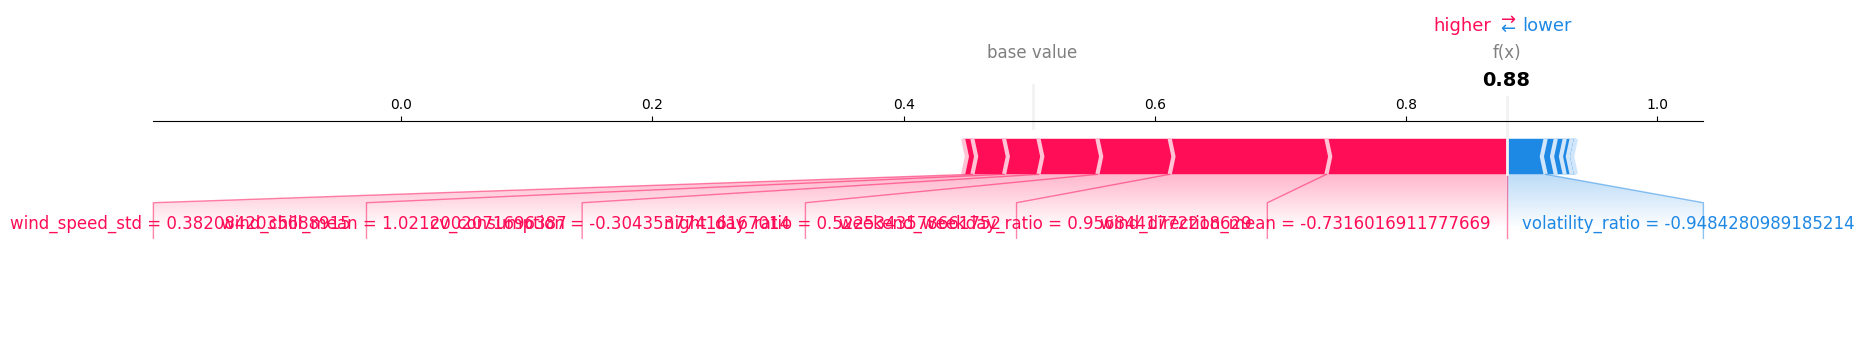

In [25]:
building_counts = df.groupby('building_id').size()
valid_buildings = building_counts[building_counts >= 5].index

residential_buildings = df_agg_full[df_agg_full['is_residential'] == 1]['building_id']

chosen_building = residential_buildings[residential_buildings.isin(valid_buildings)].iloc[0]
print(f"Odabrana zgrada: {chosen_building}")
print(f"Stvarna klasa: {df_agg_full[df_agg_full['building_id'] == chosen_building]['is_residential'].values[0]}")

building_idx = df_agg_full[df_agg_full['building_id'] == chosen_building].index[0]

shap.initjs()

print(f"Force plot za zgradu {chosen_building}")
shap.force_plot(
    explainer.expected_value[1],
    shap_values[building_idx, :, 1],
    X_final_df.iloc[building_idx],
    feature_names=final_features,
    matplotlib=True
)

Iz force plota teško je iščitati imena značajki, pa ću prikazati i waterfall plot.

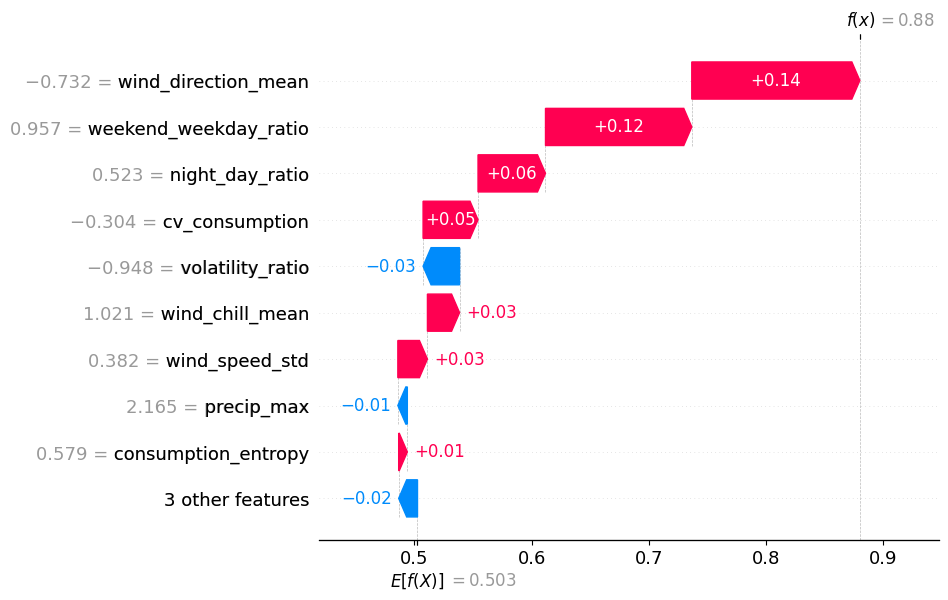

In [26]:
explanation = shap.Explanation(
    values=shap_values[building_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_final_df.iloc[building_idx].values,
    feature_names=final_features
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=True)

Ovdje se već daju iščitati neki rezultati. Zanimljivo, djeluje da najvažniji značaj ima prosječan smjer vjetra, dok malo očekivanije, bitne su i značajke koje govore o omjeru potrošnje preko vikenda/randog dana i noći/dana.

### 7.3.2. SHAP za nestambenu zgradu

Odabrana zgrada: 2
Stvarna klasa: 0


Force plot za zgradu 2


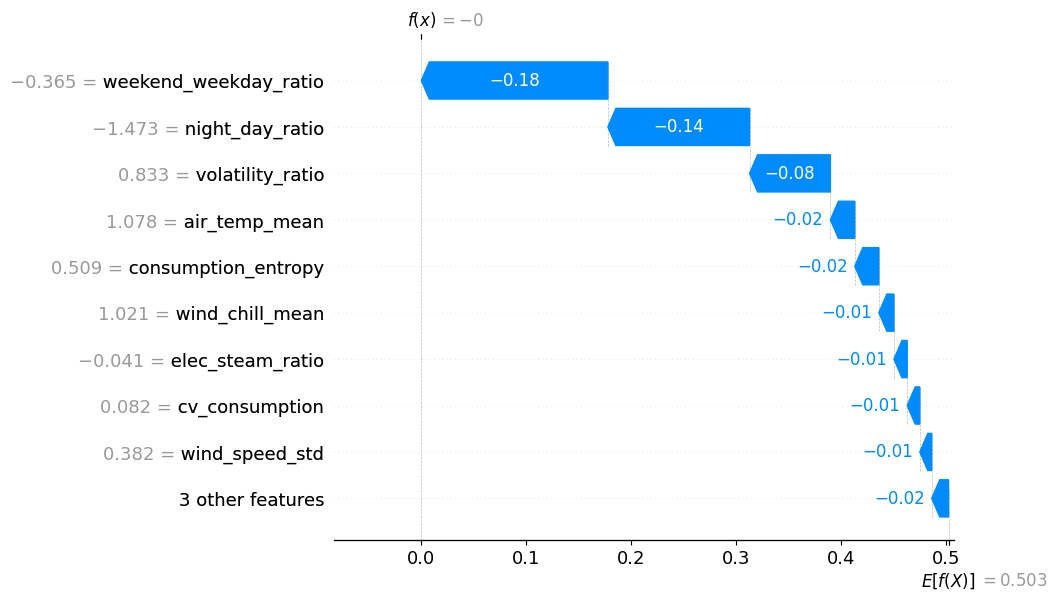

In [27]:
non_residential_buildings = df_agg_full[df_agg_full['is_residential'] == 0]['building_id']
chosen_building = non_residential_buildings[non_residential_buildings.isin(valid_buildings)].iloc[2]
print(f"Odabrana zgrada: {chosen_building}")
print(f"Stvarna klasa: {df_agg_full[df_agg_full['building_id'] == chosen_building]['is_residential'].values[0]}")

building_idx = df_agg_full[df_agg_full['building_id'] == chosen_building].index[0]

shap.initjs()

print(f"Force plot za zgradu {chosen_building}")
explanation = shap.Explanation(
    values=shap_values[building_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_final_df.iloc[building_idx].values,
    feature_names=final_features
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=True)

Najveći značaj za ovu zgradu imaju značajke omjera potrošnje vikend/radni dan i potrošnja noć/dan, što zapravo i ima smisla. Najveća razlika u potrošnji energije se stvara u vrijeme kada su obično tvornice, uredi i obrazovne ustanove zatvorene, a ljudi u stambenih objektima troše energiju i preko vikenda i po noći.

## 7.4. RIPPER

RIPPER je algoritam koji služi za pronalazak indukcijskih pravila, a zasnovan je na inkrementalnom podrezivanju sa smanjenom pogreškom.

Kao i kod SNAP-a, zbog toga što nemamo sve značajke u orginalnom skupu podataka, provest ćemo RIPPER nad agregiranim skupom podataka.

In [28]:
df_ripper = df_agg_full[final_features + ['is_residential']].copy()

X_rip = df_ripper[final_features]
y_rip = df_ripper['is_residential']

X_train_rip, X_test_rip, y_train_rip, y_test_rip = train_test_split(
    X_rip, y_rip, test_size=0.33, random_state=42, stratify=y_rip
)

train_df = X_train_rip.copy()
train_df['is_residential'] = y_train_rip.values

test_df = X_test_rip.copy()
test_df['is_residential'] = y_test_rip.values

In [29]:
ripper = lw.RIPPER(random_state=42)
ripper.fit(train_df, class_feat='is_residential', pos_class=1)

y_pred_rip = ripper.predict(test_df)
f1_rip = f1_score(y_test_rip, y_pred_rip, zero_division=0)
print(f"RIPPER baseline F1: {f1_rip:.4f}")
print("\nPravila:")
ripper.out_model()

RIPPER baseline F1: 0.1429

Pravila:
[[night_day_ratio=>0.52 ^ elec_steam_ratio=>0.6] V
[night_day_ratio=0.5-0.52 ^ wind_direction_mean=<125.29] V
[weekend_weekday_ratio=0.392-0.398 ^ air_temp_mean=22.8-25.07 ^ consumption_entropy=2.32-2.42] V
[weekend_weekday_ratio=0.392-0.398 ^ wind_direction_mean=<125.29]]


Rezultat nije baš obećavajuć, F1 score je vrlo nizak. Glavni razlog tome je mali broj podataka. Ipak, pravila koja smo dobili ukazuju na važnost omjera potrošnje energije po noći i danu (što je veći omjer, veća je šansa da je zgrada stambena).

Probat ću pronaći optimalne hiperparametre grid searchom.

In [30]:
k_values          = [1, 2, 3, 4]
prune_size_values = [0.2, 0.3, 0.4, 0.5]
dl_allowance_values = [16, 32, 48, 64]

best_f1     = -1
best_params = {}
best_model  = None

for k, prune_size, dl_allowance in product(k_values, prune_size_values, dl_allowance_values):
    try:
        model = lw.RIPPER(k=k, prune_size=prune_size, dl_allowance=dl_allowance, random_state=42)
        model.fit(train_df, class_feat='is_residential', pos_class=1)
        y_pred = model.predict(test_df)
        f1 = f1_score(y_test_rip, y_pred, zero_division=0)
        
        if f1 > best_f1:
            best_f1     = f1
            best_params = {'k': k, 'prune_size': prune_size, 'dl_allowance': dl_allowance}
            best_model  = model
    except:
        continue

print(f"\nNajbolji parametri: {best_params}")
print(f"Optimizirani RIPPER F1: {best_f1:.4f}")
print("\nOptimizirana pravila:")
best_model.out_model()


Najbolji parametri: {'k': 1, 'prune_size': 0.5, 'dl_allowance': 48}
Optimizirani RIPPER F1: 0.2308

Optimizirana pravila:
[[night_day_ratio=>0.52 ^ wind_speed_std=1.523-1.947] V
[weekend_weekday_ratio=0.392-0.398 ^ wind_direction_mean=<125.29] V
[wind_speed_std=2.19-2.234 ^ night_day_ratio=>0.52 ^ volatility_ratio=0.082-0.12] V
[air_temp_mean=22.8-25.07 ^ weekend_weekday_ratio=0.392-0.398 ^ consumption_entropy=2.32-2.42] V
[weekend_weekday_ratio=>0.405 ^ wind_direction_mean=186.11-189.74]]


Rezultat iz istog razloga, premalog broja podataka, opet nije dobar, te se zbog malih intervala vrijednosti podataka poput weekend_weekday_ratio=0.392-0.398 može pretpostaviti da se model prenaučio na skupu za učenje.

Sljedeće ćemo ograničiti broj pravila na 3 i uvjete po pravilu na 2 i vidjeti rezultat.

In [31]:
ripper_constrained = lw.RIPPER(
    k=best_params['k'],
    prune_size=best_params['prune_size'],
    dl_allowance=best_params['dl_allowance'],
    max_rules=3,
    max_rule_conds=2,
    random_state=42
)
ripper_constrained.fit(train_df, class_feat='is_residential', pos_class=1)

y_pred_constrained = ripper_constrained.predict(test_df)
f1_constrained = f1_score(y_test_rip, y_pred_constrained, zero_division=0)
print(f"\nOgraničeni RIPPER F1: {f1_constrained:.4f}")
print("\nOgraničena pravila:")
ripper_constrained.out_model()


Ograničeni RIPPER F1: 0.1905

Ograničena pravila:
[[night_day_ratio=>0.52 ^ wind_speed_std=1.523-1.947] V
[weekend_weekday_ratio=0.392-0.398 ^ wind_direction_mean=<125.29]]


F1 score je očekivano pao, ali smo dobili dva najvažnija pravila koja se lako mogu interpretirati. Ipak, budući da rezultat nije dobar, nema smisla ulaziti u dubinu točnosti tih pravila, iako dio s većom potrošnjom energije po noći ima smisla.

Ukupno, RIPPER metoda djeluje kao zanimljiv koncept koji pomaže u razumijevanju skupa podataka, ali ona bi bolje funkcionirala na većem skupu podataka, na primjer da smo ga proveli na orginalnom skupu podataka. No, to bi u ovom slučaju bilo problematično zbog vrlo velikog skupa podataka. Štoviše, zapravo sam pokušao isprobati RIPPER metodu na čitavom skupu podataka, ali nažalost nakon preko 60 minuta čekanja došlo je do memorijske greške te sam nakon toga odustao od te ideje. 